# IMPORT LIBRARIES 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,f1_score, confusion_matrix,RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix
import shap
import joblib
print("All libraries imported successfully")

All libraries imported successfully


# LOAD DATASET

In [2]:
df = pd.read_csv('aug_train.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nJob-seeking rate: {df['target'].mean()*100:.1f}%")
df.head(3)

Shape: (19158, 14)

Columns:
['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']

Target distribution:
target
0.0    14381
1.0     4777
Name: count, dtype: int64

Job-seeking rate: 24.9%


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0


# EDA

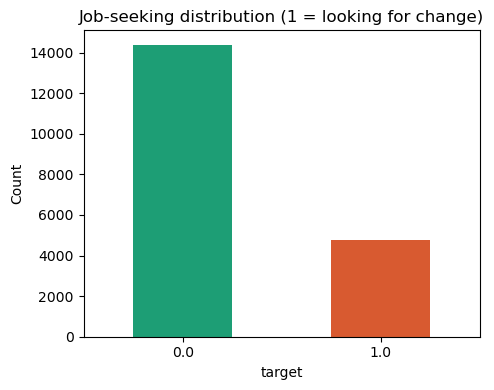

In [3]:
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar',color=['#1D9E75', '#D85A30'], edgecolor='none')
plt.title('Job-seeking distribution (1 = looking for change)')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

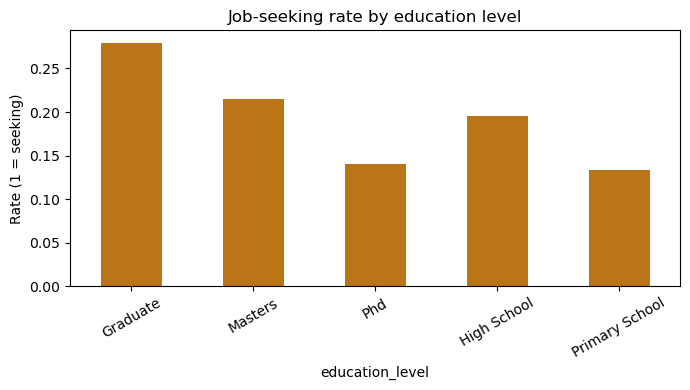

In [4]:
edu_order = ['Graduate', 'Masters', 'Phd', 'High School', 'Primary School']
edu_seek = df.groupby('education_level')['target'].mean().reindex(edu_order).dropna()
plt.figure(figsize=(7, 4))
edu_seek.plot(kind='bar', color='#BA7517', edgecolor='none')
plt.title('Job-seeking rate by education level')
plt.ylabel('Rate (1 = seeking)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

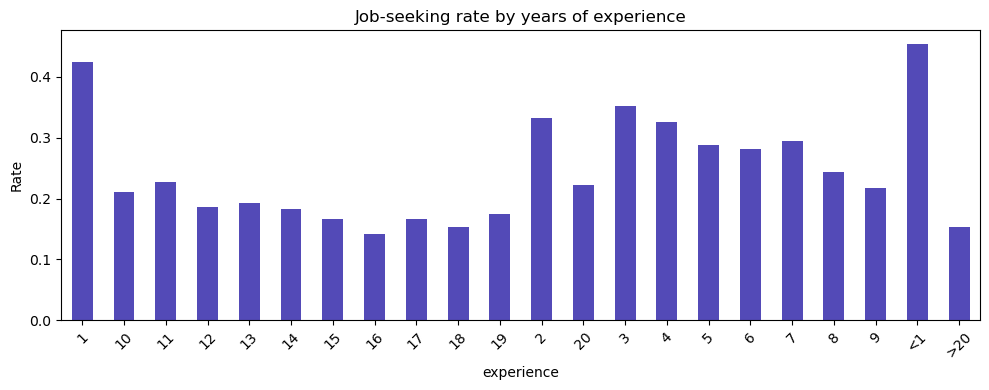

In [5]:
plt.figure(figsize=(10, 4))
exp_seek = df.groupby('experience')['target'].mean()
exp_seek.plot(kind='bar', color='#534AB7', edgecolor='none')
plt.title('Job-seeking rate by years of experience')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

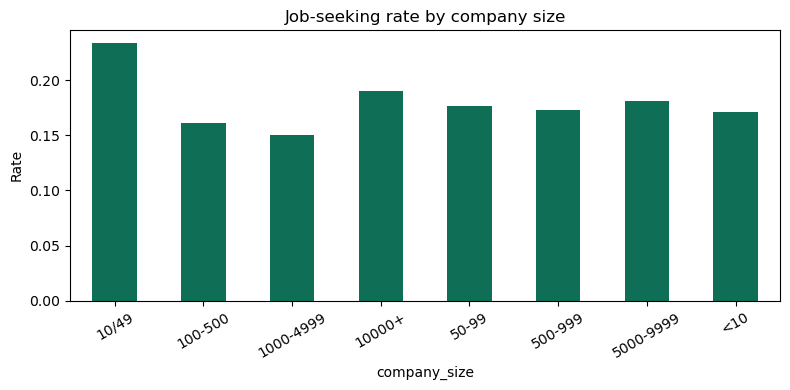

In [6]:
plt.figure(figsize=(8, 4))
size_seek = df.groupby('company_size')['target'].mean()
size_seek.plot(kind='bar', color='#0F6E56', edgecolor='none')
plt.title('Job-seeking rate by company size')
plt.ylabel('Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nMissing % per column:")
print((missing / len(df) * 100).round(1))

Columns with missing values:
company_type           6140
company_size           5938
gender                 4508
major_discipline       2813
education_level         460
last_new_job            423
enrolled_university     386
experience               65
dtype: int64

Missing % per column:
company_type           32.0
company_size           31.0
gender                 23.5
major_discipline       14.7
education_level         2.4
last_new_job            2.2
enrolled_university     2.0
experience              0.3
dtype: float64


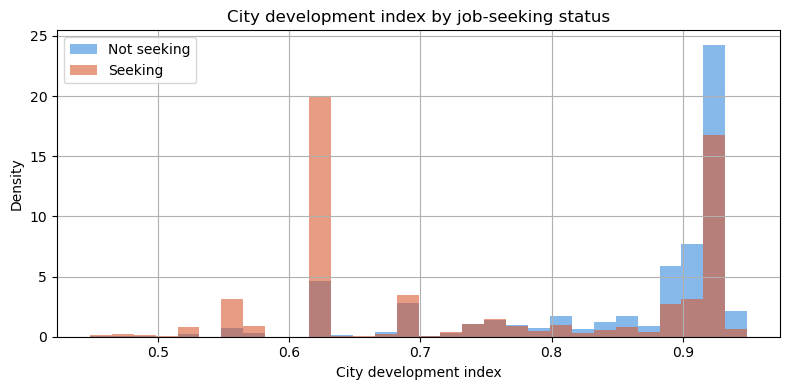

In [8]:
plt.figure(figsize=(8, 4))
df[df['target'] == 0]['city_development_index'].hist(bins=30, alpha=0.6, color='#378ADD', label='Not seeking', density=True)
df[df['target'] == 1]['city_development_index'].hist(bins=30, alpha=0.6, color='#D85A30', label='Seeking', density=True)
plt.title('City development index by job-seeking status')
plt.xlabel('City development index')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# PREPROCESSING

In [9]:
df.drop(columns=['enrollee_id'], inplace=True)
print(f"Shape after dropping ID: {df.shape}")

Shape after dropping ID: (19158, 13)


In [10]:
df['major_discipline'] = df['major_discipline'].fillna('unknown')
cat_fill_cols = ['gender', 'enrolled_university', 'education_level','company_size', 'company_type']
for col in cat_fill_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df['experience'] = df['experience'].fillna(df['experience'].mode()[0])
df['last_new_job'] = df['last_new_job'].fillna(df['last_new_job'].mode()[0])
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


In [11]:
text_col = 'major_discipline'
target_col = 'target'
structured_cols = [c for c in df.columns if c not in [text_col, target_col]]
print(f"Structured features: {structured_cols}")

Structured features: ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']


In [12]:
le = LabelEncoder()
for col in df[structured_cols].select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
print("Categorical encoding done.")

Categorical encoding done.


In [13]:
X_structured = df[structured_cols].values
scaler = StandardScaler()
X_structured_scaled = scaler.fit_transform(X_structured)
print(f"Structured features shape: {X_structured_scaled.shape}")

Structured features shape: (19158, 11)


In [14]:
tfidf = TfidfVectorizer(max_features=50)
X_text = tfidf.fit_transform(df[text_col].astype(str))
print(f"TF-IDF matrix shape: {X_text.shape}")
print(f"TF-IDF features (top 10): {tfidf.get_feature_names_out()[:10]}")

TF-IDF matrix shape: (19158, 9)
TF-IDF features (top 10): ['arts' 'business' 'degree' 'humanities' 'major' 'no' 'other' 'stem'
 'unknown']


In [15]:
X_combined = hstack([csr_matrix(X_structured_scaled), X_text])
y = df[target_col].values
print(f"Combined feature matrix shape: {X_combined.shape}")
print(f"Target distribution: {pd.Series(y).value_counts().to_dict()}")

Combined feature matrix shape: (19158, 20)
Target distribution: {0.0: 14381, 1.0: 4777}


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y,test_size=0.2,random_state=42,stratify=y)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (15326, 20)
Test size:  (3832, 20)


In [20]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE — training set:")
print(f"  Class 0 (not seeking): {(y_train_sm == 0).sum()}")
print(f"  Class 1 (seeking):     {(y_train_sm == 1).sum()}")


After SMOTE — training set:
  Class 0 (not seeking): 11504
  Class 1 (seeking):     11504


# TRAINING MODEL

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'ROC-AUC': auc, 'F1': f1}
    trained_models[name] = model
    print(f"  ROC-AUC: {auc:.4f}  |  F1: {f1:.4f}\n")

print("Best by AUC:", max(results, key=lambda k: results[k]['ROC-AUC']))

Training Logistic Regression...
  ROC-AUC: 0.7528  |  F1: 0.5395

Training Random Forest...
  ROC-AUC: 0.7786  |  F1: 0.5352

Training XGBoost...
  ROC-AUC: 0.7839  |  F1: 0.5449

Best by AUC: XGBoost


# EVALUATE

In [22]:
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print(f"=== {best_name} ===")
print(classification_report(y_test, y_pred,
      target_names=['Not seeking', 'Seeking']))

=== XGBoost ===
              precision    recall  f1-score   support

 Not seeking       0.85      0.85      0.85      2877
     Seeking       0.55      0.54      0.54       955

    accuracy                           0.77      3832
   macro avg       0.70      0.70      0.70      3832
weighted avg       0.77      0.77      0.77      3832



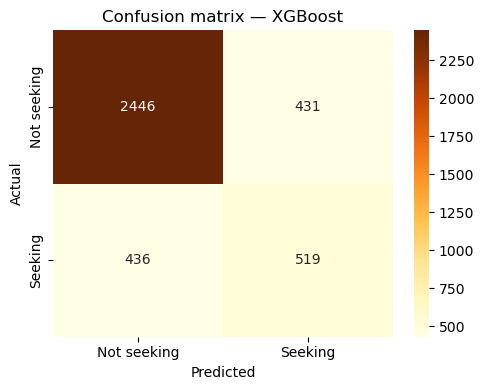

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Not seeking', 'Seeking'],
            yticklabels=['Not seeking', 'Seeking'])
plt.title(f'Confusion matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

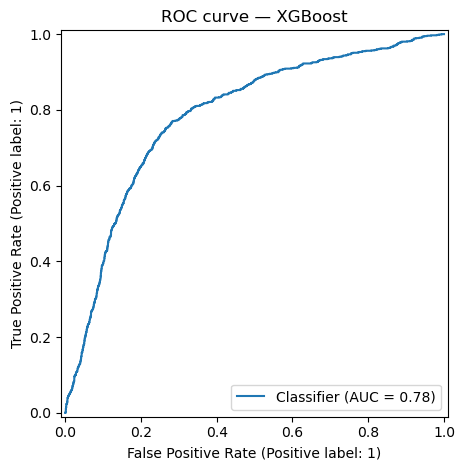

In [24]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f'ROC curve — {best_name}')
plt.tight_layout()
plt.show()

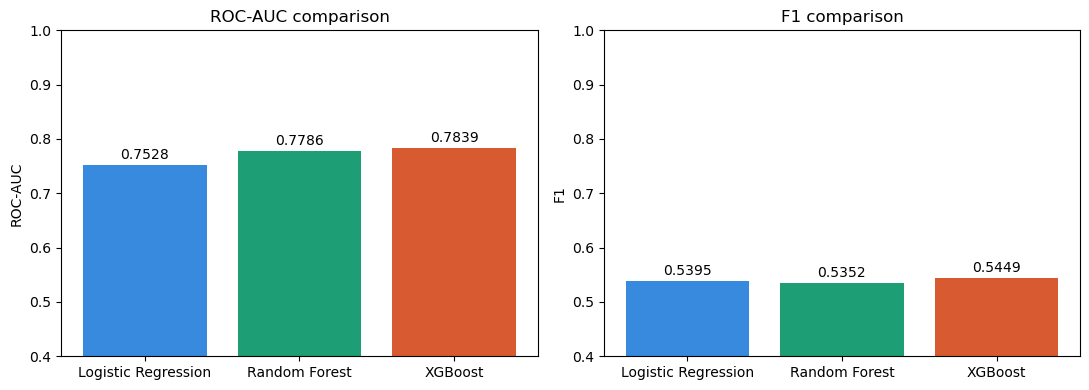

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(results.keys())
colors = ['#378ADD', '#1D9E75', '#D85A30']

for ax, metric in zip(axes, ['ROC-AUC', 'F1']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_title(f'{metric} comparison')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# SHAP AND SAVING MODEL

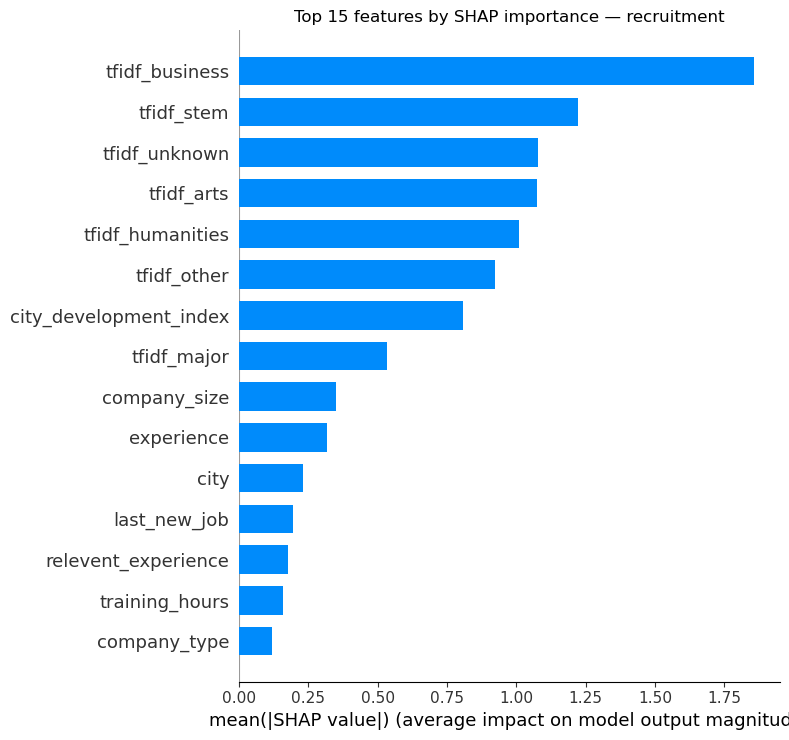

In [26]:
xgb_model = trained_models['XGBoost']
X_sample_sparse = X_test[:500]
X_sample_dense = X_sample_sparse.toarray()
tfidf_feature_names = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
all_feature_names = structured_cols + tfidf_feature_names
X_sample_df = pd.DataFrame(X_sample_dense, columns=all_feature_names)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample_df)
plt.figure()
shap.summary_plot(shap_values, X_sample_df, plot_type='bar',max_display=15, show=False)
plt.title('Top 15 features by SHAP importance — recruitment')
plt.tight_layout()
plt.savefig('shap_recruitment_summary.png', dpi=150, bbox_inches='tight')
plt.show()

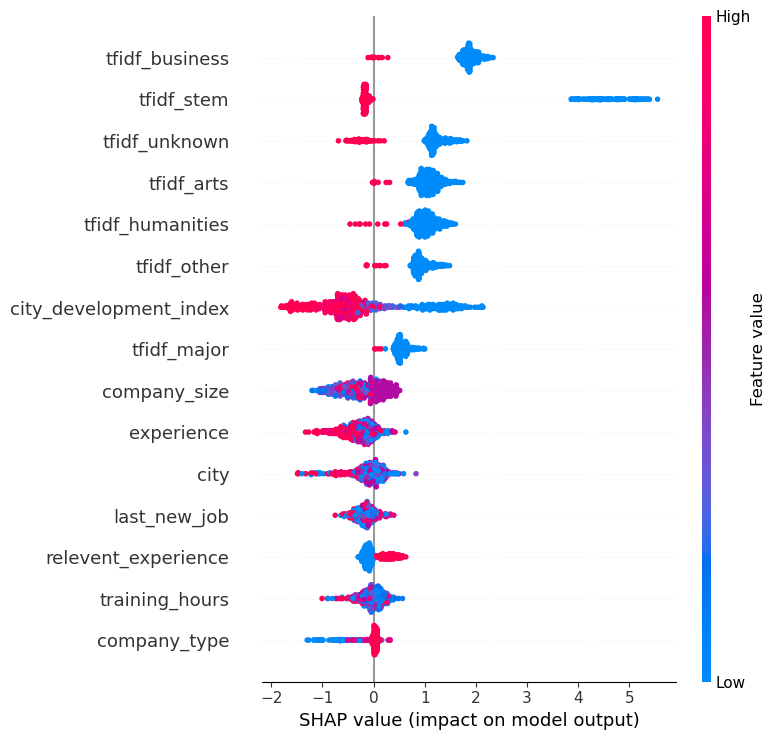

In [27]:
plt.figure()
shap.summary_plot(shap_values, X_sample_df, max_display=15, show=False)
plt.tight_layout()
plt.show()

In [28]:
joblib.dump(xgb_model, 'recruitment_model.pkl')
joblib.dump(scaler, 'recruitment_scaler.pkl')
joblib.dump(tfidf, 'recruitment_tfidf.pkl')
print("Saved: recruitment_model.pkl")
print("Saved: recruitment_scaler.pkl")
print("Saved: recruitment_tfidf.pkl")
print(f"\nNotebook 4 complete! Suite finished.")
print(f"Best model: {best_name}")
for metric, val in results[best_name].items():
    print(f"{metric}: {val:.4f}")

Saved: recruitment_model.pkl
Saved: recruitment_scaler.pkl
Saved: recruitment_tfidf.pkl

Notebook 4 complete! Suite finished.
Best model: XGBoost
ROC-AUC: 0.7839
F1: 0.5449
